In [87]:
import pandas as pd   
# Load the dataset
df = pd.read_csv("supply_chain_data.csv")
df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


In [88]:
# Quick look at the data
print("Shape:", df.shape)
print(df.head())

Shape: (100, 24)
  Product type   SKU      Price  Availability  Number of products sold  \
0     haircare  SKU0  69.808006            55                      802   
1     skincare  SKU1  14.843523            95                      736   
2     haircare  SKU2  11.319683            34                        8   
3     skincare  SKU3  61.163343            68                       83   
4     skincare  SKU4   4.805496            26                      871   

   Revenue generated Customer demographics  Stock levels  Lead times  \
0        8661.996792            Non-binary            58           7   
1        7460.900065                Female            53          30   
2        9577.749626               Unknown             1          10   
3        7766.836426            Non-binary            23          13   
4        2686.505152            Non-binary             5           3   

   Order quantities  ...  Location Lead time  Production volumes  \
0                96  ...    Mumbai   

In [89]:
# Step 1: Inspect structure and quality
from pprint import pprint

print("\nColumn names:")
pprint(list(df.columns))

print("\nData types and non-null counts:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())



Column names:
['Product type',
 'SKU',
 'Price',
 'Availability',
 'Number of products sold',
 'Revenue generated',
 'Customer demographics',
 'Stock levels',
 'Lead times',
 'Order quantities',
 'Shipping times',
 'Shipping carriers',
 'Shipping costs',
 'Supplier name',
 'Location',
 'Lead time',
 'Production volumes',
 'Manufacturing lead time',
 'Manufacturing costs',
 'Inspection results',
 'Defect rates',
 'Transportation modes',
 'Routes',
 'Costs']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated 

In [90]:
# Step 2: Descriptive statistics
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\nNumeric columns:", list(numeric_cols))

print("\nDescriptive statistics for numeric columns:")
print(df[numeric_cols].describe())


Numeric columns: ['Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Defect rates', 'Costs']

Descriptive statistics for numeric columns:
            Price  Availability  Number of products sold  Revenue generated  \
count  100.000000    100.000000               100.000000         100.000000   
mean    49.462461     48.400000               460.990000        5776.048187   
std     31.168193     30.743317               303.780074        2732.841744   
min      1.699976      1.000000                 8.000000        1061.618523   
25%     19.597823     22.750000               184.250000        2812.847151   
50%     51.239831     43.500000               392.500000        6006.352023   
75%     77.198228     75.000000               704.250000        8253.976921   
max     99.171329    100.000000    

In [91]:
# Step 3: KPIs and SQL-style analysis
!pip install duckdb
import duckdb

# Total revenue
query_total_revenue = """
    SELECT SUM("Revenue generated") AS total_revenue
    FROM df
"""
result = duckdb.query(query_total_revenue).df()
print("\nTotal Revenue from all products:")
print(result)

# Example: Revenue by Location
query_rev_by_location = """
    SELECT "Location", SUM("Revenue generated") AS revenue
    FROM df
    GROUP BY "Location"
    ORDER BY revenue DESC
"""
rev_by_location = duckdb.query(query_rev_by_location).df()
print("\nRevenue by Location:")
print(rev_by_location.head())



Total Revenue from all products:
   total_revenue
0  577604.818738

Revenue by Location:
    Location        revenue
0     Mumbai  137755.026877
1    Kolkata  137077.551005
2    Chennai  119142.815748
3  Bangalore  102601.723882
4      Delhi   81027.701225


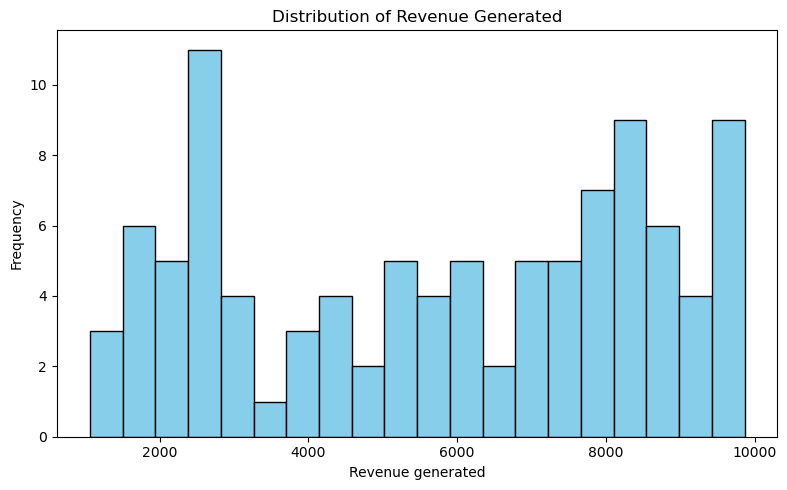

In [92]:
# Step 4: EDA visualizations
import matplotlib.pyplot as plt

# Histogram of Revenue generated
plt.figure(figsize=(8, 5))
plt.hist(df["Revenue generated"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Revenue Generated")
plt.xlabel("Revenue generated")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

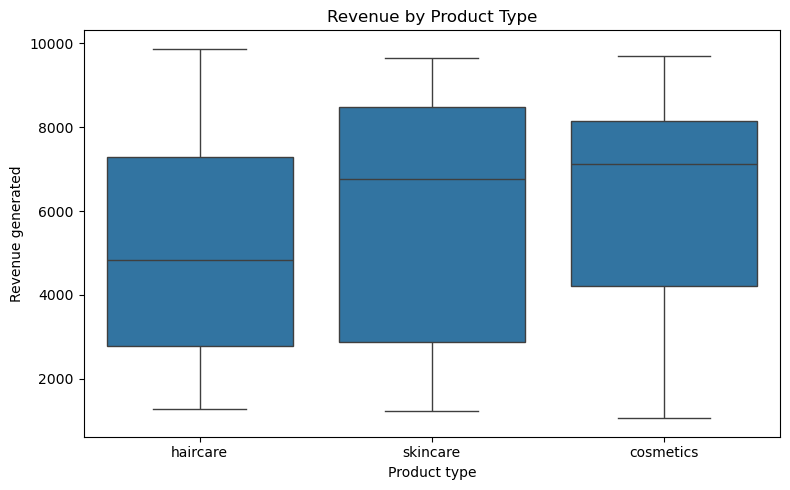

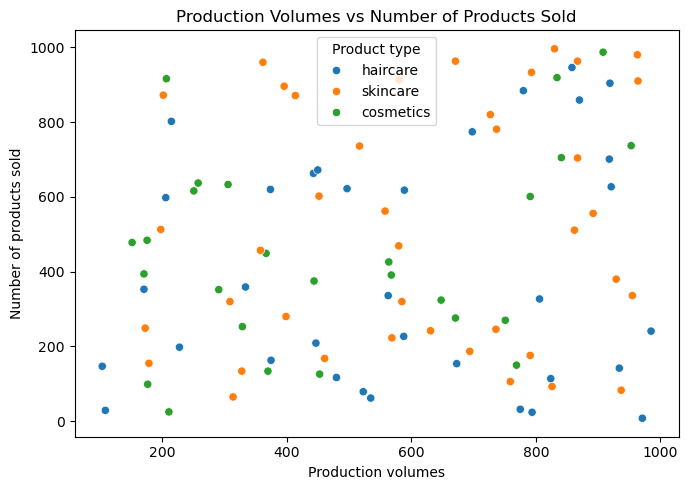

In [93]:
# Step 4b: More EDA visualizations
import seaborn as sns

# Boxplot of Revenue by Product type
plt.figure(figsize=(8, 5))
sns.boxplot(x="Product type", y="Revenue generated", data=df)
plt.title("Revenue by Product Type")
plt.tight_layout()
plt.show()

# Scatter plot: Production volumes vs Number of products sold
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="Production volumes",
    y="Number of products sold",
    hue="Product type"
)
plt.title("Production Volumes vs Number of Products Sold")
plt.tight_layout()
plt.show()

In [94]:
# Step 5: Feature preparation for ML
from sklearn.model_selection import train_test_split

# Target: demand proxy
target_col = "Number of products sold"

# Categorical columns (object)
cat_cols = df.select_dtypes(include=["object"]).columns

# Numeric columns (excluding target)
num_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col != target_col
]

print("Categorical columns:", list(cat_cols))
print("Numeric feature columns:", num_cols)

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Define X (features) and y (target)
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Categorical columns: ['Product type', 'SKU', 'Customer demographics', 'Shipping carriers', 'Supplier name', 'Location', 'Inspection results', 'Transportation modes', 'Routes']
Numeric feature columns: ['Price', 'Availability', 'Revenue generated', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Defect rates', 'Costs']
Train shape: (80, 135) Test shape: (20, 135)


In [95]:
# Step 6: Standardize features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)


Scaled train shape: (80, 135)


In [96]:
# Step 7: Build the TensorFlow neural network model
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_train_scaled.shape[1]

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=[input_dim]),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # regression output
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

D:\ANACONDA\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 128)                 │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,777 (108.50 KB)

 Trainable params: 27,777 (108.50 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
# Step 8: Train the neural network

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 447ms/step - loss: 296440.0938 - val_loss: 287888.7500
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 295905.4375 - val_loss: 287515.3750
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 295345.0625 - val_loss: 287111.1562
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 294745.7812 - val_loss: 286662.6875
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 294089.6875 - val_loss: 286174.0000
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 293323.0625 - val_loss: 285639.6250
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 292457.4375 - val_loss: 285046.4375
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 291510.0000 - val_loss: 284383.5625
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 290353.4375 - val_loss: 283647.6250
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 289053.2500 - val_loss: 282838.5625
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 

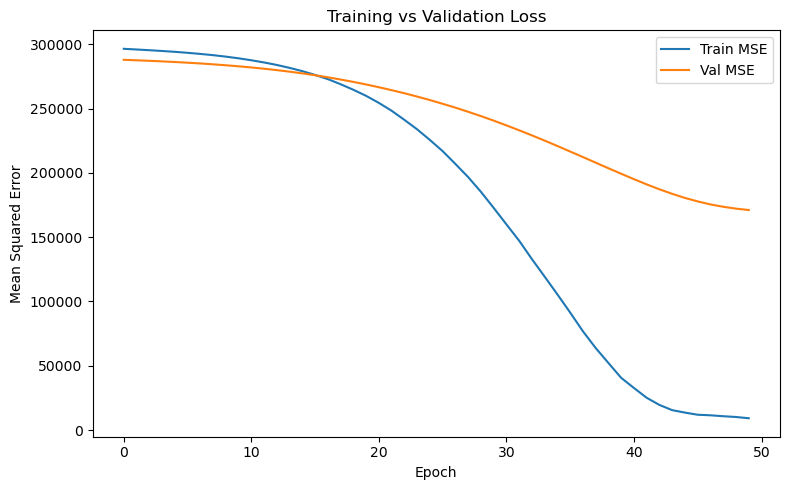

In [98]:
# Step 9: Plot training and validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [99]:
# Step 10: Evaluate on test set
from sklearn.metrics import mean_squared_error

y_pred_nn = model.predict(X_test_scaled)

mse_nn = mean_squared_error(y_test, y_pred_nn)
print(f"Mean Squared Error on Test Set (NN): {mse_nn:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Mean Squared Error on Test Set (NN): 128529.438


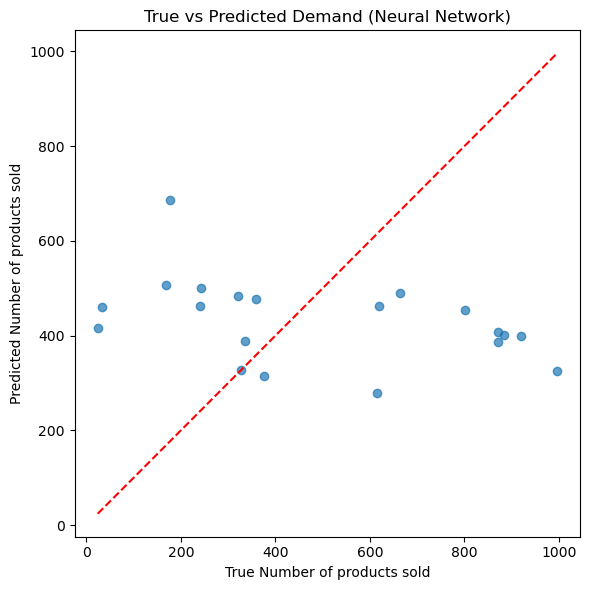

In [100]:
# Step 11: Plot true vs predicted (neural network)
import matplotlib.pyplot as plt  # re-import is okay in a new step

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.7)
plt.xlabel("True Number of products sold")
plt.ylabel("Predicted Number of products sold")
plt.title("True vs Predicted Demand (Neural Network)")

# perfect prediction line
min_val = min(y_test.min(), y_pred_nn.min())
max_val = max(y_test.max(), y_pred_nn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.tight_layout()
plt.show()

In [101]:
# Step 12: Save the trained NN model
model.save("demand_forecasting_model.keras")
print("Saved as demand_forecasting_model.keras")

Saved as demand_forecasting_model.keras


In [102]:
from tensorflow import keras
import numpy as np

# Load from the new .keras file
loaded_model = keras.models.load_model("demand_forecasting_model.keras")

# Take one sample from X_test
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)

predicted_sales = loaded_model.predict(sample_scaled)[0][0]
true_sales = y_test.iloc[0]

print("True sales:", true_sales)
print("Predicted sales:", predicted_sales)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
True sales: 663
Predicted sales: 489.30734


In [103]:
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved!")

Scaler saved!
